# Sweep G from low and high synaptic gating initial conditions

Compare late excitatory and inhibitory firing rates after independent starts at each G.
This notebook uses the AAL connectivity and static-FIC settings from `examples.ipynb`.

- Draw independent per-region `sn0` and `sg0` values from Uniform(0, 0.1) for the low start and Uniform(0.3, 1) for the high start. Draw once with a fixed initialization seed and reuse the same vectors at every G.
- G ranges from 0 to 2.5 in steps of 0.5. Each run lasts 120 s; discard the first 10 s.
- Plasticity and decay are off. J is constant **within** a run and recomputed at each G using `1 + 0.75 * G * C.sum(axis=0)`.
- Noise SD is the model default, 0.01 nA. The same seed is used for all runs, pairing the noise across initial conditions. Set `sigma = 0.0` below for a deterministic comparison.
- Every run resets its initial conditions. States are not passed between neighboring G values.

A persistent difference over this finite window is a candidate for initial-state dependence, not proof of bistability or hysteresis. Inspect transients and repeat with longer durations and additional seeds before making that interpretation. No BOLD signal is computed.

Use the **fasthdmf312** environment with the rebuilt library; restart an already-running kernel first.

In [1]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastdyn_fic_dmf as dmf

repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
C = np.loadtxt(repo_root / "data/SCs/Averaged_SCs/aal/healthy_average.csv", delimiter=",")
C = 0.2 * C / C.max()
N = C.shape[0]

print(f"Connectivity: {N} regions, maximum weight = {C.max():.2f}")
print(f"Simulator: {dmf.__file__}")
assert {"sn0", "sg0"} <= dmf.default_params(C=C).keys(), "Use the rebuilt library in fasthdmf312."

Connectivity: 90 regions, maximum weight = 0.20
Simulator: /Users/ivanmindlin/miniforge3/envs/fasthdmf312/lib/python3.12/site-packages/fastdyn_fic_dmf/__init__.py


In [2]:
# Edit the sweep and initial states here. Gating also accepts length-N arrays.
G_values = np.arange(2.0, 4.0 + 0.25, 0.5)
initialization_seed = 1
rng = np.random.default_rng(initialization_seed)
initial_conditions = {
    "low": {"sn0": rng.uniform(0.0, 0.1, N), "sg0": rng.uniform(0.0, 0.1, N)},
    "high": {"sn0": rng.uniform(0.3, 1.0, N), "sg0": rng.uniform(0.3, 1.0, N)},
}
duration_s = 120.0
burn_in_s = 10.0
seed = 1
sigma = 0.00

# The simulator saves one firing-rate sample per millisecond (10 microsteps at dt=0.1 ms).
nb_steps = int(round(duration_s * 1000))
burn_in_steps = int(round(burn_in_s * 1000))
assert 0 <= burn_in_steps < nb_steps
assert np.all(np.diff(G_values) > 0)

# Store region means and decimated network traces, not every full rate array.
trace_stride = 10  # 10 ms between displayed trace samples
trace_time_s = (np.arange(0, nb_steps, trace_stride) + 1) / 1000
condition_names = list(initial_conditions)
mean_rate_e = np.empty((len(condition_names), len(G_values), N))
mean_rate_i = np.empty_like(mean_rate_e)
network_trace_e = np.empty((len(condition_names), len(G_values), len(trace_time_s)))
network_trace_i = np.empty_like(network_trace_e)

print(f"{len(condition_names) * len(G_values)} simulations, {duration_s:g} s each; "
      f"averages use the final {duration_s - burn_in_s:g} s.")

10 simulations, 120 s each; averages use the final 110 s.


## Single-node sweep of recurrent excitation and inhibition

Select node 0 and calculate its strength from the normalized full connectivity matrix.
Simulate that node alone with `G = 0`, `sigma = 0`, and plasticity/decay disabled.
Here `J = 1 + alpha * node_strength`: **G is intentionally omitted from this J rule**.
The model parameter `w` is the recurrent excitatory weight w+.

Reuse the selected node's low/high `sn0` and `sg0` draws from the settings above at every grid point.
Each heatmap entry is its excitatory firing rate averaged across time after burn-in
(10–120 s with the current settings), for one initial state per condition.
Both heatmaps share a color scale. The reported maximum is across grid points;
there is no maximization across time or random initial draws.


In [7]:
node_index = 0  # Zero-based index in the original connectivity matrix
node_strength = float(C.sum(axis=0)[node_index])
JGABA_values = np.arange(1.6, 1.8 + 0.025, 0.025)
w_plus_values = np.arange(2.25, 2.75 + 0.025, 0.025)
node_conditions = ["low", "high"]
node_initial_conditions = {
    condition: {
        "sn0": float(initial_conditions[condition]["sn0"][node_index]),
        "sg0": float(initial_conditions[condition]["sg0"][node_index]),
    }
    for condition in node_conditions
}
node_mean_rate_e = np.empty((len(node_conditions), len(JGABA_values), len(w_plus_values)))

print(f"Node {node_index}: strength = {node_strength:.6f}")
print(f"Initial gating: {node_initial_conditions}")
print(f"G = sigma = 0; averaging {burn_in_s:g}–{duration_s:g} s")
node_sweep_start = perf_counter()
for JGABA_index, JGABA in enumerate(JGABA_values):
    node_J = JGABA
    for w_index, w_plus in enumerate(w_plus_values):
        for condition_index, condition in enumerate(node_conditions):
            node_params = dmf.default_params(
                C=np.zeros((1, 1)), G=0.0, sigma=0.0,
                J=node_J, w=float(w_plus), dt=0.1, seed=seed,
                with_plasticity=False, with_decay=False,
                return_rate=True, return_bold=False, return_fic=False,
                **node_initial_conditions[condition],
            )
            node_rates_e, node_rates_i, _, _ = dmf.run(node_params, nb_steps)
            if not (np.isfinite(node_rates_e).all() and np.isfinite(node_rates_i).all()):
                raise ValueError(f"Non-finite rates: JGABA={JGABA}, w+={w_plus}, {condition}")
            node_mean_rate_e[condition_index, JGABA_index, w_index] = (
                node_rates_e[0, burn_in_steps:].mean()
            )
            del node_rates_e, node_rates_i
    print(f"JGABA = {JGABA:g}, J = {node_J:.6f}: complete")
print(f"{node_mean_rate_e.size} simulations complete in {perf_counter() - node_sweep_start:.1f} s")


Node 0: strength = 0.410698
Initial gating: {'low': {'sn0': 0.051182162470025674, 'sg0': 0.06913370352777413}, 'high': {'sn0': 0.8237525713536284, 'sg0': 0.392525189133437}}
G = sigma = 0; averaging 10–120 s
JGABA = 1.6, J = 1.600000: complete
JGABA = 1.625, J = 1.625000: complete
JGABA = 1.65, J = 1.650000: complete
JGABA = 1.675, J = 1.675000: complete
JGABA = 1.7, J = 1.700000: complete
JGABA = 1.725, J = 1.725000: complete
JGABA = 1.75, J = 1.750000: complete
JGABA = 1.775, J = 1.775000: complete
JGABA = 1.8, J = 1.800000: complete
JGABA = 1.825, J = 1.825000: complete
JGABA = 1.85, J = 1.850000: complete
JGABA = 1.875, J = 1.875000: complete
JGABA = 1.9, J = 1.900000: complete
JGABA = 1.925, J = 1.925000: complete
JGABA = 1.95, J = 1.950000: complete
JGABA = 1.975, J = 1.975000: complete
JGABA = 2, J = 2.000000: complete
JGABA = 2.025, J = 2.025000: complete
24 simulations complete in 424.8 s


low: maximum time-averaged rate = 49.477953 Hz at JGABA=1.6, w+=2.975
high: maximum time-averaged rate = 49.477953 Hz at JGABA=1.6, w+=2.975


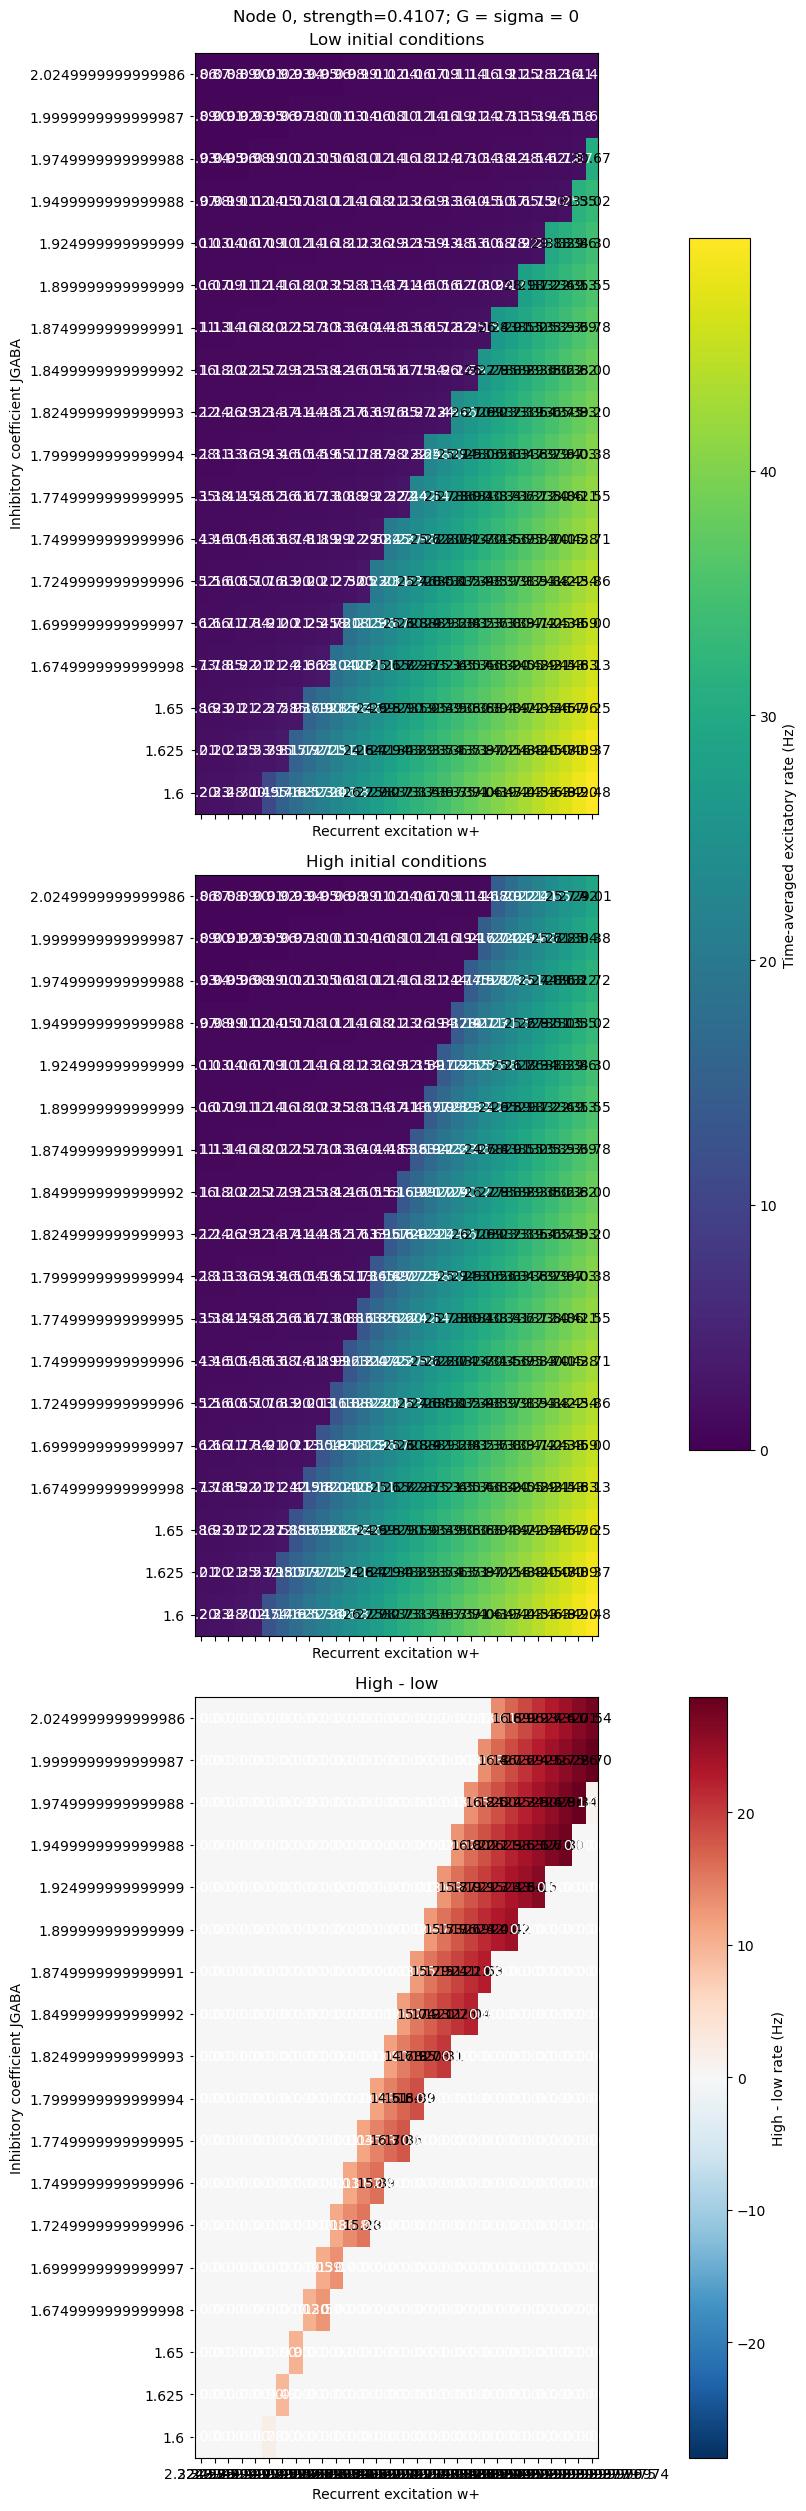

In [14]:

node_vmax = max(float(node_mean_rate_e.max()), 1e-12)

# Add a third panel showing the high-minus-low difference
node_diff = node_mean_rate_e[1] - node_mean_rate_e[0]
node_diff_limit = max(float(np.abs(node_diff).max()), 1e-12)

node_fig, node_axes = plt.subplots(3, 1, figsize=(8, 25), sharex=True, sharey=True,
                                  layout="constrained")

for condition_index, (node_ax, condition) in enumerate(zip(node_axes[:2], node_conditions)):
    node_image = node_ax.imshow(node_mean_rate_e[condition_index], origin="lower",
                               aspect="auto", cmap="viridis", vmin=0, vmax=node_vmax)
    node_ax.set_xticks(np.arange(len(w_plus_values)), labels=w_plus_values)
    node_ax.set_yticks(np.arange(len(JGABA_values)), labels=JGABA_values)
    node_ax.set(xlabel="Recurrent excitation w+", title=f"{condition.capitalize()} initial conditions")
    node_ax.set_ylabel("Inhibitory coefficient JGABA" if condition_index == 0 else "")
    for JGABA_index in range(len(JGABA_values)):
        for w_index in range(len(w_plus_values)):
            value = node_mean_rate_e[condition_index, JGABA_index, w_index]
            node_ax.text(w_index, JGABA_index, f"{value:.2f}", ha="center", va="center",
                         color="white" if value < 0.5 * node_vmax else "black")
    peak_JGABA, peak_w = np.unravel_index(
        np.argmax(node_mean_rate_e[condition_index]), node_mean_rate_e[condition_index].shape
    )
    print(f"{condition}: maximum time-averaged rate = "
          f"{node_mean_rate_e[condition_index, peak_JGABA, peak_w]:.6f} Hz "
          f"at JGABA={JGABA_values[peak_JGABA]:g}, w+={w_plus_values[peak_w]:g}")

diff_ax = node_axes[2]
diff_image = diff_ax.imshow(node_diff, origin="lower", aspect="auto",
                           cmap="RdBu_r", vmin=-node_diff_limit, vmax=node_diff_limit)
diff_ax.set_xticks(np.arange(len(w_plus_values)), labels=w_plus_values)
diff_ax.set_yticks(np.arange(len(JGABA_values)), labels=JGABA_values)
diff_ax.set(xlabel="Recurrent excitation w+", title="High - low")
diff_ax.set_ylabel("Inhibitory coefficient JGABA")
for JGABA_index in range(len(JGABA_values)):
    for w_index in range(len(w_plus_values)):
        diff_value = node_diff[JGABA_index, w_index]
        diff_ax.text(w_index, JGABA_index, f"{diff_value:.2f}", ha="center", va="center",
                     color="white" if abs(diff_value) < 0.5 * node_diff_limit else "black")

node_fig.colorbar(node_image, ax=node_axes[:2], label="Time-averaged excitatory rate (Hz)")
node_fig.colorbar(diff_image, ax=node_axes[2], label="High - low rate (Hz)")
node_fig.suptitle(f"Node {node_index}, strength={node_strength:.4f}; G = sigma = 0")
plt.show()


## Find pairs meeting both rate criteria

Select grid points with **3 ≤ low-start mean rate ≤ 4 Hz** and
**high-start mean rate − low-start mean rate > 10 Hz**.
The means use the same post-burn-in time window as the single-node sweep.
The table is sorted by decreasing rate difference and includes the equivalent
`alpha = (JGABA - 1) / node_strength`.

These are matches on the tested grid for the two fixed initial states above,
not a guarantee for every draw from the low/high ranges. Change the grid in
the single-node sweep to refine the boundaries; no interpolation is used.


2 of 189 grid points satisfy 3 <= low rate <= 4 Hz and high - low > 10 Hz.
  w_plus    JGABA    alpha  low_rate_Hz  high_rate_Hz  high_minus_low_Hz
2.550000 1.725000 1.765288     3.047460     18.324383          15.276924
2.475000 1.675000 1.643544     3.233110     15.818403          12.585294


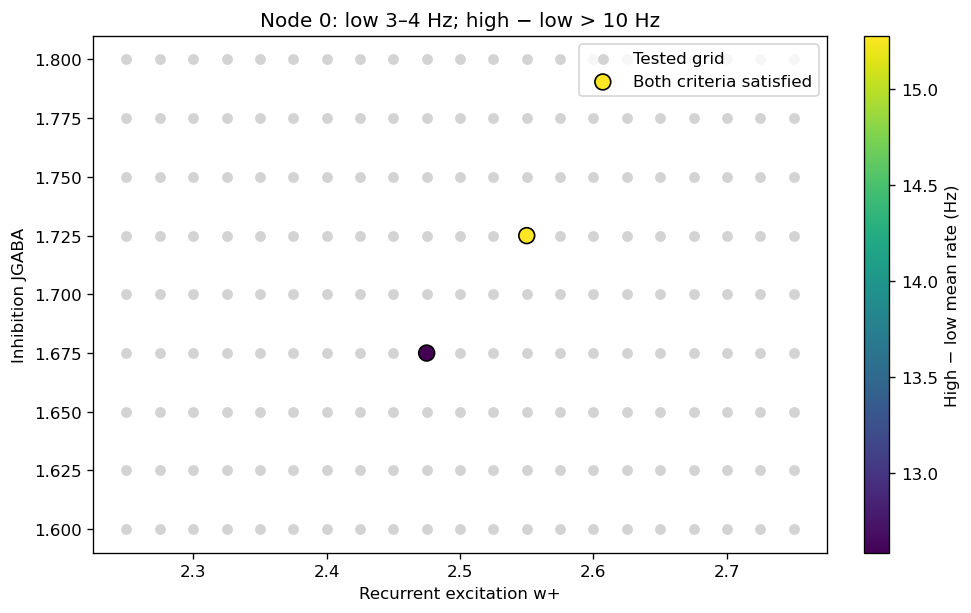

In [4]:
# Apply both criteria to the time averages computed by the node sweep above.
low_rate_min = 3.0
low_rate_max = 4.0
minimum_rate_gap = 10.0

low_rates = node_mean_rate_e[node_conditions.index("low")]
high_rates = node_mean_rate_e[node_conditions.index("high")]
rate_gap = high_rates - low_rates
matching_pairs = (
    (low_rates >= low_rate_min)
    & (low_rates <= low_rate_max)
    & (rate_gap > minimum_rate_gap)
)
j_indices, w_indices = np.nonzero(matching_pairs)
qualifying_pairs = pd.DataFrame({
    "w_plus": w_plus_values[w_indices],
    "JGABA": JGABA_values[j_indices],
    "alpha": (JGABA_values[j_indices] - 1) / node_strength,
    "low_rate_Hz": low_rates[matching_pairs],
    "high_rate_Hz": high_rates[matching_pairs],
    "high_minus_low_Hz": rate_gap[matching_pairs],
}).sort_values("high_minus_low_Hz", ascending=False).reset_index(drop=True)

print(f"{len(qualifying_pairs)} of {matching_pairs.size} grid points satisfy "
      f"{low_rate_min:g} <= low rate <= {low_rate_max:g} Hz and "
      f"high - low > {minimum_rate_gap:g} Hz.")
if qualifying_pairs.empty:
    print("No matches on this grid. This does not exclude matches between grid points.")
else:
    print(qualifying_pairs.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

pair_fig, pair_ax = plt.subplots(figsize=(8, 5), layout="constrained")
w_grid, j_grid = np.meshgrid(w_plus_values, JGABA_values)
pair_ax.scatter(w_grid, j_grid, color="lightgray", s=30, label="Tested grid")
if not qualifying_pairs.empty:
    pair_points = pair_ax.scatter(
        qualifying_pairs["w_plus"], qualifying_pairs["JGABA"],
        c=qualifying_pairs["high_minus_low_Hz"], cmap="viridis", s=90,
        edgecolors="black", label="Both criteria satisfied",
    )
    pair_fig.colorbar(pair_points, ax=pair_ax, label="High − low mean rate (Hz)")
pair_ax.set(xlabel="Recurrent excitation w+", ylabel="Inhibition JGABA",
            title=f"Node {node_index}: low {low_rate_min:g}–{low_rate_max:g} Hz; "
                  f"high − low > {minimum_rate_gap:g} Hz")
pair_ax.legend()
plt.show()


## Sweep G and w+ with JGABA tied to G

Use `JGABA = 1.675 + 0.75 * G * node_strength`, with G = 0–1 in steps of 0.1
and w+ = 2.3–2.6 in steps of 0.025. Keep the same isolated node, fixed low/high
initial states, zero noise, disabled plasticity/decay, and post-burn-in averaging window.
This is 143 parameter pairs and 286 simulations of 120 s with the current settings.

**The one-node connectivity remains zero:** G changes JGABA through the specified
rule, but there is no network coupling input. A coupled-network G sweep is a
different experiment.

Compare low/high mean rates on the same color scale and their difference in the
third panel. Outlined squares and the table identify `3 <= low <= 4 Hz` and
`high - low > 10 Hz`, for these two initial states.


In [20]:
gw_G_values = np.linspace(0.0, 1.0, 11)
gw_w_values = np.linspace(2.3, 2.6, 13)
gw_J_values = 1.675 + 0.75 * gw_G_values * node_strength

In [21]:
gw_J_values 

array([1.675     , 1.70580234, 1.73660469, 1.76740703, 1.79820938,
       1.82901172, 1.85981406, 1.89061641, 1.92141875, 1.9522211 ,
       1.98302344])

In [24]:
node_strength * 2.1 * 0.75

0.6468492254501076

Node 0, strength=0.410698; sigma=0
286 simulations; averaging 10–120 s
G=0.0, JGABA=1.675000: complete
G=0.1, JGABA=1.705802: complete
G=0.2, JGABA=1.736605: complete
G=0.3, JGABA=1.767407: complete
G=0.4, JGABA=1.798209: complete
G=0.5, JGABA=1.829012: complete
G=0.6, JGABA=1.859814: complete
G=0.7, JGABA=1.890616: complete
G=0.8, JGABA=1.921419: complete
G=0.9, JGABA=1.952221: complete
G=1.0, JGABA=1.983023: complete
Sweep complete in 110.1 s
1 of 143 pairs satisfy 3 <= low <= 4 Hz and high - low > 10 Hz.
       G   w_plus    JGABA  low_rate_Hz  high_rate_Hz  high_minus_low_Hz
0.000000 2.475000 1.675000     3.233110     15.818403          12.585294


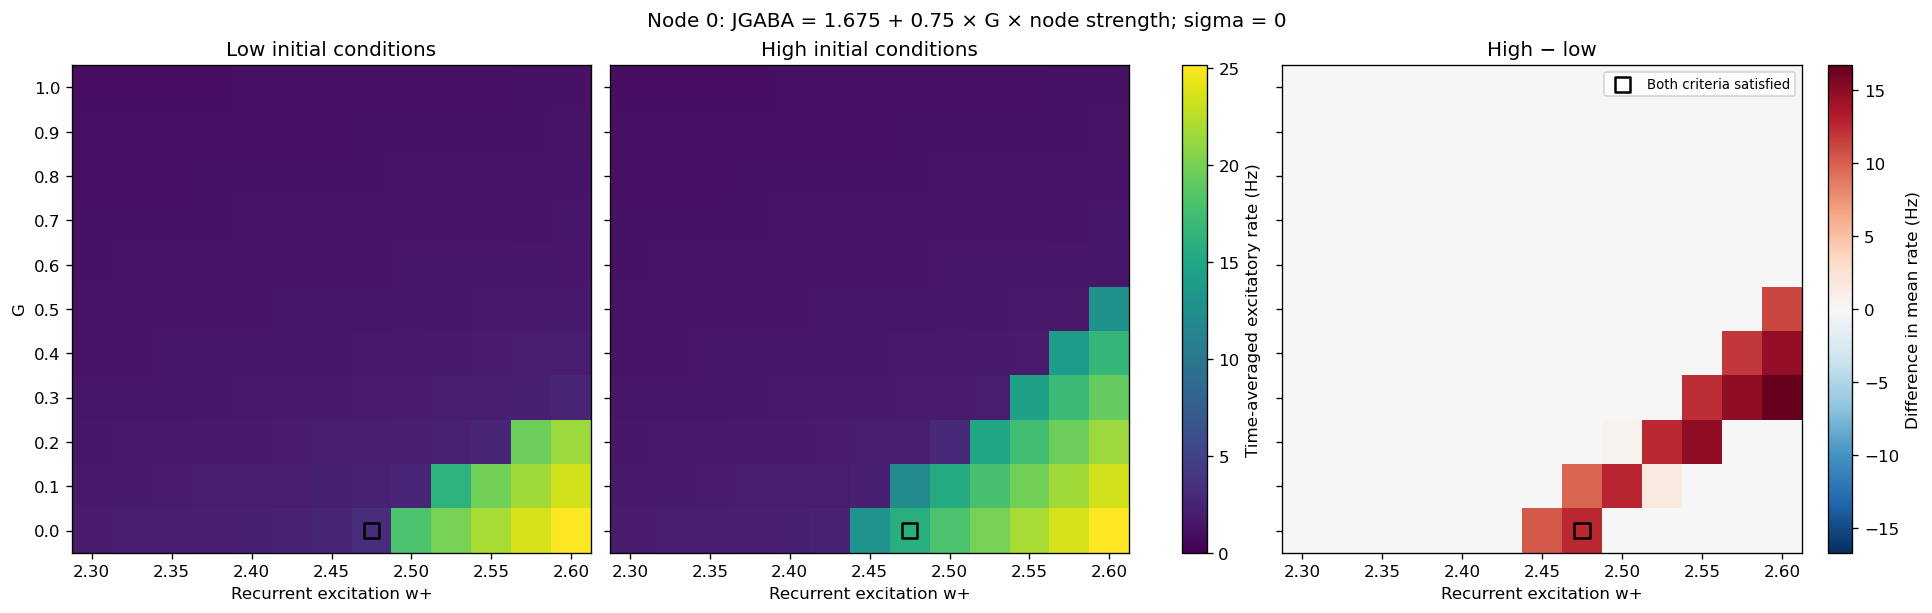

In [ ]:
# Isolated-node G/w+ sweep; G enters JGABA but C=0 removes network input.
gw_G_values = np.linspace(0.0, 1.0, 11)
gw_w_values = np.linspace(2.3, 2.6, 13)
gw_J_values = 1 + 0.75 * gw_G_values * node_strength
gw_mean_rate_e = np.empty((len(node_conditions), len(gw_G_values), len(gw_w_values)))

print(f"Node {node_index}, strength={node_strength:.6f}; sigma=0")
print(f"{gw_mean_rate_e.size} simulations; averaging {burn_in_s:g}–{duration_s:g} s")
gw_start = perf_counter()
for g_index, gw_G in enumerate(gw_G_values):
    for w_index, gw_w in enumerate(gw_w_values):
        for condition_index, condition in enumerate(node_conditions):
            gw_params = dmf.default_params(
                C=np.zeros((1, 1)), G=float(gw_G), sigma=0.0,
                J=float(gw_J_values[g_index]), w=float(gw_w), dt=0.1, seed=seed,
                with_plasticity=False, with_decay=False,
                return_rate=True, return_bold=False, return_fic=False,
                **node_initial_conditions[condition],
            )
            gw_rates_e, gw_rates_i, _, _ = dmf.run(gw_params, nb_steps)
            if not (np.isfinite(gw_rates_e).all() and np.isfinite(gw_rates_i).all()):
                raise ValueError(f"Non-finite rates: G={gw_G}, w+={gw_w}, {condition}")
            gw_mean_rate_e[condition_index, g_index, w_index] = (
                gw_rates_e[0, burn_in_steps:].mean()
            )
            del gw_rates_e, gw_rates_i
    print(f"G={gw_G:.1f}, JGABA={gw_J_values[g_index]:.6f}: complete")
print(f"Sweep complete in {perf_counter() - gw_start:.1f} s")

gw_low = gw_mean_rate_e[node_conditions.index("low")]
gw_high = gw_mean_rate_e[node_conditions.index("high")]
gw_gap = gw_high - gw_low
gw_matches = (gw_low >= 3.0) & (gw_low <= 4.0) & (gw_gap > 10.0)
gw_g_indices, gw_w_indices = np.nonzero(gw_matches)
gw_qualifying_pairs = pd.DataFrame({
    "G": gw_G_values[gw_g_indices],
    "w_plus": gw_w_values[gw_w_indices],
    "JGABA": gw_J_values[gw_g_indices],
    "low_rate_Hz": gw_low[gw_matches],
    "high_rate_Hz": gw_high[gw_matches],
    "high_minus_low_Hz": gw_gap[gw_matches],
}).sort_values("high_minus_low_Hz", ascending=False).reset_index(drop=True)
print(f"{len(gw_qualifying_pairs)} of {gw_matches.size} pairs satisfy "
      "3 <= low <= 4 Hz and high - low > 10 Hz.")
if gw_qualifying_pairs.empty:
    print("No matches on this grid; matches between grid points are not excluded.")
else:
    print(gw_qualifying_pairs.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

gw_vmax = max(float(gw_mean_rate_e.max()), 1e-12)
gw_gap_limit = max(float(np.abs(gw_gap).max()), 1e-12)
gw_fig, gw_axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True,
                              layout="constrained")
for gw_ax, gw_values, gw_title in zip(gw_axes, (gw_low, gw_high, gw_gap),
                                     ("Low initial conditions", "High initial conditions", "High − low")):
    if gw_title == "High − low":
        gw_image = gw_ax.pcolormesh(gw_w_values, gw_G_values, gw_values, shading="nearest",
                                   cmap="RdBu_r", vmin=-gw_gap_limit, vmax=gw_gap_limit)
        gw_fig.colorbar(gw_image, ax=gw_ax, label="Difference in mean rate (Hz)")
    else:
        gw_image = gw_ax.pcolormesh(gw_w_values, gw_G_values, gw_values, shading="nearest",
                                   cmap="viridis", vmin=0, vmax=gw_vmax)
        if gw_title == "High initial conditions":
            gw_fig.colorbar(gw_image, ax=gw_axes[:2], label="Time-averaged excitatory rate (Hz)")
    if gw_matches.any():
        gw_ax.scatter(gw_w_values[gw_w_indices], gw_G_values[gw_g_indices],
                      marker="s", s=85, facecolors="none", edgecolors="black",
                      linewidths=1.5, label="Both criteria satisfied")
    gw_ax.set(xlabel="Recurrent excitation w+", title=gw_title)
    gw_ax.set_yticks(gw_G_values)
gw_axes[0].set_ylabel("G")
if gw_matches.any():
    gw_axes[-1].legend(loc="upper right", fontsize=8)
gw_fig.suptitle(f"Node {node_index}: JGABA = 1.675 + 0.75 × G × node strength; sigma = 0")
plt.show()


## Run independent low/high starts

For each region, average all post-burn-in firing-rate samples. The network mean is then the equally weighted mean of those regional averages. Trace decimation affects only the transient plots, not the averages. Change the explicit J assignment below if you want a different inhibition protocol.

In [3]:
sweep_start = perf_counter()
for g_index, G in enumerate(G_values):
    for condition_index, condition in enumerate(condition_names):
        params = dmf.default_params(
            C=C, G=float(G), dt=0.1, seed=seed, sigma=sigma,
            with_plasticity=False, with_decay=False,
            return_rate=True, return_bold=False, return_fic=False,
            **initial_conditions[condition],
        )
        params["J"] = 1 + 0.75 * G * C.sum(axis=0)
        rates_e, rates_i, _, _ = dmf.run(params, nb_steps)
        if not (np.isfinite(rates_e).all() and np.isfinite(rates_i).all()):
            raise ValueError(f"Non-finite rates at G={G}, condition={condition}")

        mean_rate_e[condition_index, g_index] = rates_e[:, burn_in_steps:].mean(axis=1)
        mean_rate_i[condition_index, g_index] = rates_i[:, burn_in_steps:].mean(axis=1)
        network_trace_e[condition_index, g_index] = rates_e.mean(axis=0)[::trace_stride]
        network_trace_i[condition_index, g_index] = rates_i.mean(axis=0)[::trace_stride]
        del rates_e, rates_i

    print(f"G = {G:.2f}: both starts complete ({perf_counter() - sweep_start:.1f} s elapsed)")

print(f"Sweep complete in {perf_counter() - sweep_start:.1f} s.")

G = 2.00: both starts complete (12.8 s elapsed)
G = 2.50: both starts complete (25.5 s elapsed)
G = 3.00: both starts complete (38.3 s elapsed)
G = 3.50: both starts complete (51.4 s elapsed)
G = 4.00: both starts complete (64.5 s elapsed)
Sweep complete in 64.5 s.


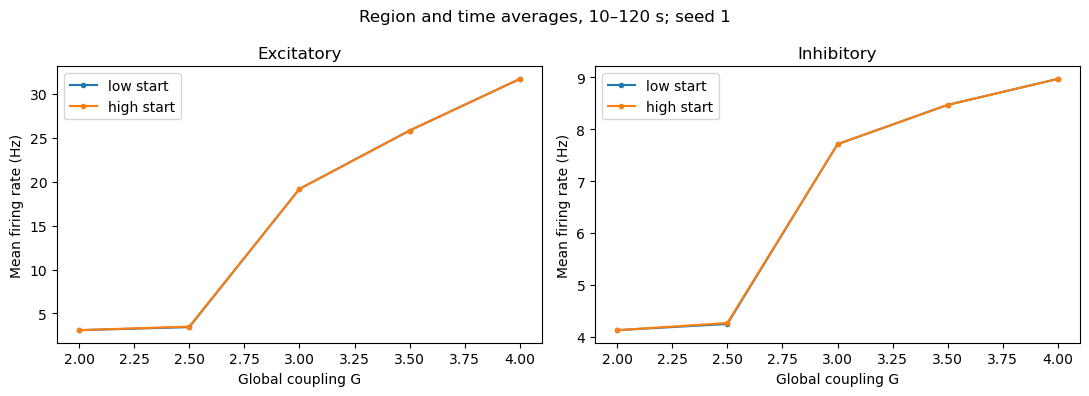

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, region_means, population in zip(
    axes, (mean_rate_e, mean_rate_i), ("Excitatory", "Inhibitory")
):
    for condition_index, condition in enumerate(condition_names):
        ax.plot(G_values, region_means[condition_index].mean(axis=1), "o-",
                markersize=3, label=f"{condition} start")
    ax.set(xlabel="Global coupling G", ylabel="Mean firing rate (Hz)", title=population)
    ax.legend()
fig.suptitle(f"Region and time averages, {burn_in_s:g}–{duration_s:g} s; seed {seed}")
fig.tight_layout()
plt.show()

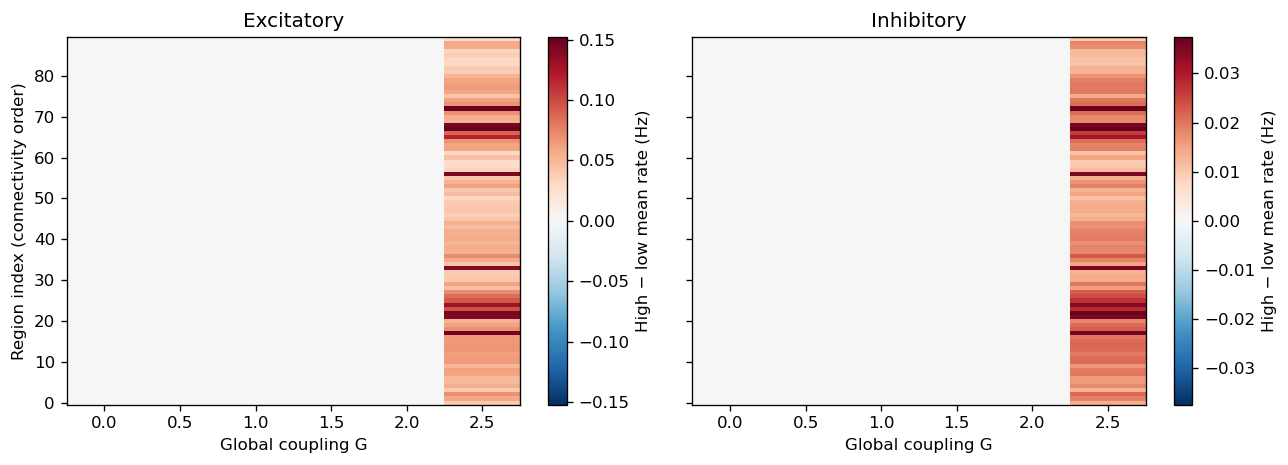

  G  low_E_Hz  high_E_Hz  low_I_Hz  high_I_Hz  regional_RMS_difference_E_Hz
  0   3.37324    3.37324   4.20884    4.20884                             0
0.5   3.23705    3.23705   4.16518    4.16518                             0
  1   3.13917    3.13917   4.13323    4.13323                             0
1.5    3.0852     3.0852     4.116      4.116                             0
  2   3.10229    3.10229   4.12362    4.12362                    2.8532e-12
2.5   3.44656    3.51006   4.24258    4.26184                      0.070595


In [5]:
# Region-wise differences retain spatial changes that a network mean could hide.
low_index = condition_names.index("low")
high_index = condition_names.index("high")
difference_e = mean_rate_e[high_index] - mean_rate_e[low_index]
difference_i = mean_rate_i[high_index] - mean_rate_i[low_index]
rms_difference_e = np.sqrt(np.mean(difference_e**2, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, difference, population in zip(axes, (difference_e, difference_i), ("Excitatory", "Inhibitory")):
    limit = max(float(np.abs(difference).max()), 1e-12)
    mesh = ax.pcolormesh(G_values, np.arange(N), difference.T, shading="nearest",
                         cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set(xlabel="Global coupling G", title=population)
    fig.colorbar(mesh, ax=ax, label="High − low mean rate (Hz)")
axes[0].set_ylabel("Region index (connectivity order)")
fig.tight_layout()
plt.show()

summary = pd.DataFrame({
    "G": G_values,
    "low_E_Hz": mean_rate_e[low_index].mean(axis=1),
    "high_E_Hz": mean_rate_e[high_index].mean(axis=1),
    "low_I_Hz": mean_rate_i[low_index].mean(axis=1),
    "high_I_Hz": mean_rate_i[high_index].mean(axis=1),
    "regional_RMS_difference_E_Hz": rms_difference_e,
})
print(summary.to_string(index=False, float_format=lambda value: f"{value:.6g}"))

## Inspect transients

The default trace selection is the G with the largest regional RMS difference in late excitatory rates. You can set `trace_G` to any G in the sweep. The shaded interval is excluded from the averages. Check whether the two trajectories settle, converge slowly, or remain variable.

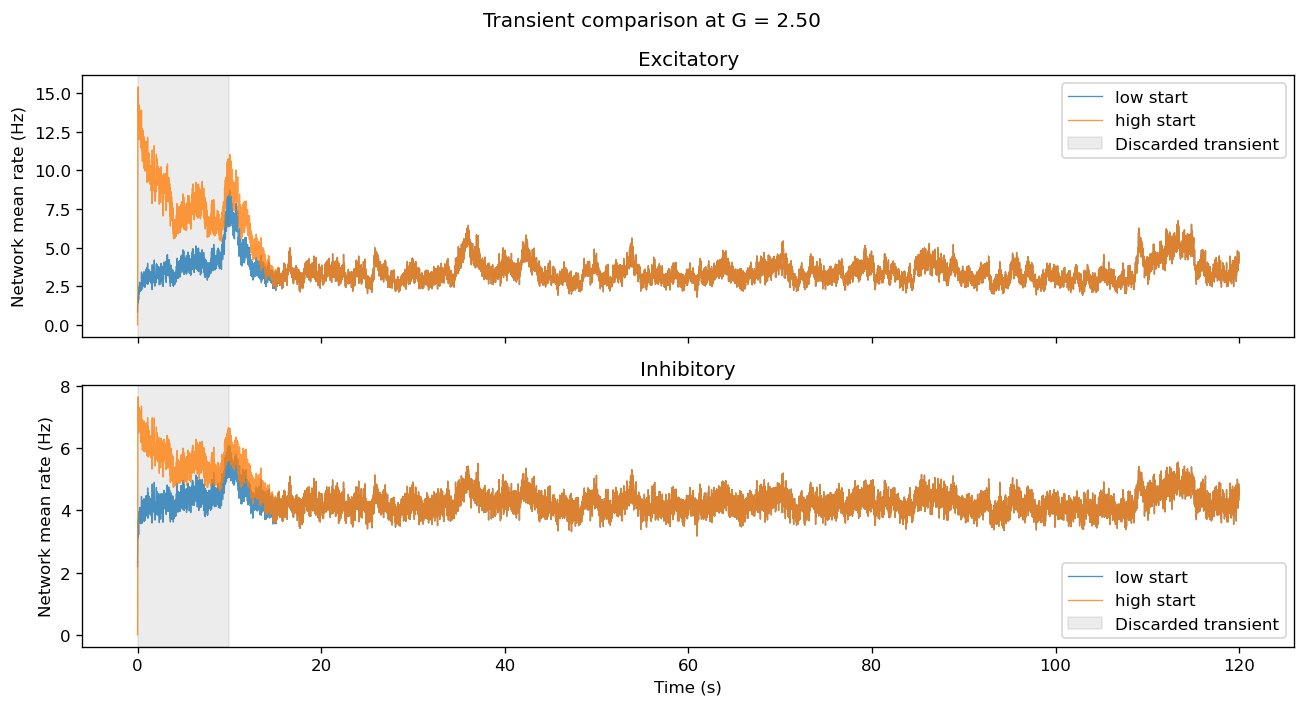

In [6]:
trace_G = float(G_values[np.argmax(rms_difference_e)])
trace_index = int(np.argmin(np.abs(G_values - trace_G)))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, traces, population in zip(axes, (network_trace_e, network_trace_i), ("Excitatory", "Inhibitory")):
    for condition_index, condition in enumerate(condition_names):
        ax.plot(trace_time_s, traces[condition_index, trace_index], linewidth=0.8,
                alpha=0.8, label=f"{condition} start")
    ax.axvspan(0, burn_in_s, color="gray", alpha=0.15, label="Discarded transient")
    ax.set(ylabel="Network mean rate (Hz)", title=population)
    ax.legend()
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Transient comparison at G = {G_values[trace_index]:.2f}")
fig.tight_layout()
plt.show()